# The one Wednesday a month the VIX won't calm down 🎯
### Did the VIX settlement auction — the one a famous paper accused of being pushed — leave tracks in the tape?

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Faded after 2018?: Mixed](https://img.shields.io/badge/Faded_after_2018%3F-Mixed-8b949e?style=flat-square)

Every month, billions of dollars of VIX futures and options stop trading and get paid out at a **single number**: the *settlement print*, computed from a special auction of S&P-500 options at the Wednesday open, exactly 30 days before the next monthly S&P option expiry.

In 2018 two academics, **Griffin & Shams**, published a paper with a needle in the title — *"Manipulation in the VIX?"* — showing that at that precise auction, trading volume spikes in exactly the deep out-of-the-money options that move the formula, and the settlement print systematically lands **away** from where the VIX was trading just before and after. Lawsuits followed. CBOE tweaked the auction.

We ask a simpler, testable question: **can you see that Wednesday in the ordinary daily VIX chart?** No tick data, no settlement prints — just the open, high, low and close that anyone can download.

> 📓 **Plain-language layer.** Want the regressions, the placebo and the robustness screens? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Up front:** the VIX index itself is **not tradable** — this is a forensics study, not a strategy. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vix_settlement_day import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    VIX, SPX = data.load_real()
    SETT = data.settlement_calendar()
    DF = st.day_frame(VIX, SPX, settlements=SETT)
else:
    VIX = SPX = SETT = DF = None
print("real cache present:", HAVE_REAL,
      "| settlements:", (0 if SETT is None else len(SETT)),
      "| days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2004-01-02', 'end': '2026-06-30', 'asof': '2026-06-30', 'n_sett': 270, 'n_wed': 899, 'n_overlap': 40, 'n_known': 18, 'tuesdays': ['2008-02-19', '2014-03-18', '2019-03-19', '2022-03-15', '2024-06-18', '2025-03-18', '2026-05-19'], 'levels': [('open gap ln(O/C-1), mean', 0.043, 0.016, 0.11, None), ('|open gap|', 2.41, 2.185, 1.3, 0.9), ('intraday ln(C/O), mean', -0.238, -0.762, 1.06, None), ('|intraday|', 5.0, 4.468, 1.48, None), ('|close-close|', 5.861, 4.88, 2.42, 1.73), ('range (H-L)/C-1', 10.088, 9.078, 2.17, 0.98), ('SPX close-close, mean', -0.079, 0.09, -2.06, -1.77)], 'n_sett_exfomc': 230, 'n_wed_exfomc': 797, 'inter_all': (-0.179, -2.3, 0.249, 0.427, 2.56, 1169), 'inter_ex': (-0.195, -2.42, 0.302, 0.497, 2.86, 1027), 'placebo': {'obs': 0.497, 'mean': -0.023, 'sd': 0.172, 'p': 0.0025, 'draws': 2000, 'seeds': 25}, 'robust': [('drop exact-zero gaps (stale-open artefact)', 0.496, 2.86, 986), ('winsorise gap/intr at 1%/99%', 0.447, 2.81, 1027)], 'fade_inter': {'pre': (0.468, 2.31, 148), 'post': (0.49, 1.53, 82)}, 'fade_level': {'all_pre': 3.1, 'all_post': 0.18, 'ex_pre': 2.21, 'ex_post': -0.2}, 'split': '2018-01-01', 'trade': {'gross': -0.024, 't0': -0.05, 't_vs': 0.67, 'n': 262, 'other': -0.361, 'net': -0.524, 'net_yr': -6.29, 'cost_bps': 25.0}, 'syn': [(0.0, 0.025, 0.25), (0.5, 0.525, 5.22)], 'fp_vix': '2f08bb9304e8', 'fp_spx': '731fc130d08d'}


real cache present: True | settlements: 270 | days: 5658


## The answer first

| Question | Answer |
|---|---|
| Can you see settlement Wednesday in the daily VIX bar? | **Yes — but not where you'd look.** The day isn't reliably *wilder* (that turned out to be mostly Fed days in disguise). The real track is subtler: it's the one day the **morning move refuses to fade**. |
| Is it luck? | Unlikely — placebo calendars produce it ~**0.3%** of the time. |
| Can you trade it? | **No.** The index isn't tradable, and the tradable echo is worth roughly zero before costs, negative after. |
| Did it stop after the paper and the lawsuits? | **Not really** — the loud part faded, the fingerprint didn't. |

## The settlement calendar — a rule, not a mystery

The settlement Wednesday is fixed by contract: **30 days before the third Friday of the following month** (with holiday adjustments — occasionally it's a Tuesday). We rebuilt the whole 2004-2026 calendar from that rule and checked it against 18 official CBOE dates, including all 7 holiday-shifted Tuesdays. That gives us **270 settlement days** to compare against **899 ordinary Wednesdays**.

In [2]:
assert data.verify_calendar() >= 18
if HAVE_REAL:
    tue = [str(d.date()) for d in SETT[SETT.weekday == 1]]
    print(len(SETT), 'settlements on the calendar |', int(DF['sett'].sum()), 'on the tape')
    print('holiday-shifted Tuesdays:', tue)
else:
    print(R['n_sett'], 'settlements | Tuesdays:', R['tuesdays'])

270 settlements on the calendar | 270 on the tape
holiday-shifted Tuesdays: ['2008-02-19', '2014-03-18', '2019-03-19', '2022-03-15', '2024-06-18', '2025-03-18', '2026-05-19']


## First look: is settlement day just louder? Mostly a red herring

The obvious guess — the VIX jumps around more on settlement day — *looks* true at first (the average full-day move is 5.9% of the index level vs 4.9% on other Wednesdays). But **40 of the 270 settlement days are also FOMC announcement days** — the Fed's Wednesday press conferences land in exactly the same mid-month slot. Strip those out and the "louder day" almost entirely evaporates. The chart shows the before/after.

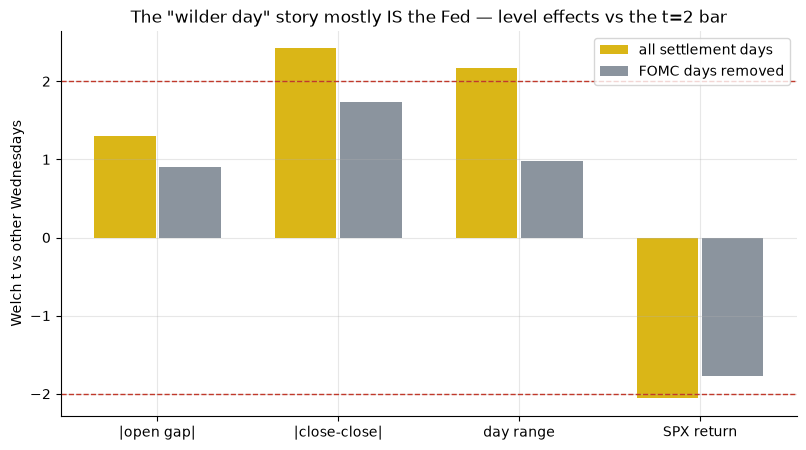

In [3]:
labels = ['|open gap|', '|close-close|', 'day range', 'SPX return']
t_all  = [1.30, 2.42, 2.17, -2.06]
t_ex   = [0.90, 1.73, 0.98, -1.77]
x = np.arange(len(labels))
fig, ax = plt.subplots()
ax.bar(x - .18, t_all, .34, color=AMBER, label='all settlement days')
ax.bar(x + .18, t_ex, .34, color=GREY, label='FOMC days removed')
for yy in (2, -2): ax.axhline(yy, color=RED, lw=1, ls='--')
ax.set_xticks(x, labels); ax.set_ylabel('Welch t vs other Wednesdays')
ax.set_title('The "wilder day" story mostly IS the Fed — level effects vs the t=2 bar')
ax.legend(); plt.show()

> 🔬 **For the quants.** Every pre-registered level metric (jump size, day volatility, range, SPX drift) is below *t* = 2 once the FOMC overlap is controlled — the full Welch table with both columns is in notebook 02.

## The real track: the gap that refuses to fade

Here's the VIX's normal morning habit: when it *opens* well above or below yesterday's close, the day tends to **walk it back** — opening gaps fade into the close. It's one of the most reliable small regularities in the vol tape.

**Except on settlement Wednesday.** On the 270 settlement days, the relationship flips: the morning gap **carries on** into the close instead of fading. That is exactly the shape you'd expect if the settlement auction *pushes option prices* at the open — the push is in the actual traded book, so the index doesn't snap back the way a noise gap does.

The scatter below shows both regimes: each dot is a day, morning gap on the x-axis, rest of the day on the y-axis.

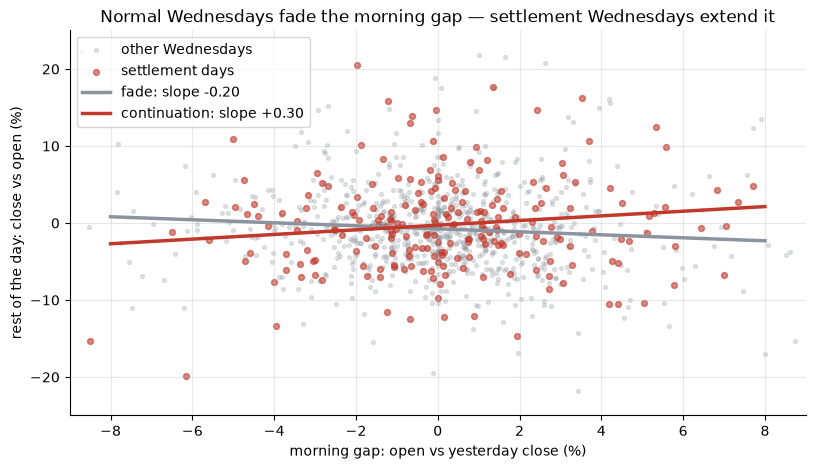

In [4]:
if HAVE_REAL:
    d = st.event_sample(DF, ex_fomc=True)
    s, o = d[d['sett']], d[~d['sett']]
    fig, ax = plt.subplots()
    ax.scatter(o['gap']*100, o['intr']*100, s=8, alpha=.25, color=GREY,
               label='other Wednesdays')
    ax.scatter(s['gap']*100, s['intr']*100, s=18, alpha=.6, color=RED,
               label='settlement days')
    for g, c, lb in ((o, GREY, 'fade'), (s, RED, 'continuation')):
        b = np.polyfit(g['gap'], g['intr'], 1)
        xs = np.linspace(-8, 8, 20)
        ax.plot(xs, (b[0]*xs/100 + b[1])*100, color=c, lw=2.5,
                label=f'{lb}: slope {b[0]:+.2f}')
    ax.set_xlim(-9, 9); ax.set_ylim(-25, 25)
    ax.set_xlabel('morning gap: open vs yesterday close (%)')
    ax.set_ylabel('rest of the day: close vs open (%)')
    ax.set_title('Normal Wednesdays fade the morning gap — settlement Wednesdays extend it')
    ax.legend(); plt.show()
else:
    print('cache missing — canonical slopes:', R['inter_ex'][0], 'vs', R['inter_ex'][2])

The grey line tilts **down** (slope -0.20: a gap up tends to be given back); the red line tilts **up** (slope +0.30: a gap up keeps going). The flip is worth a robust *t* of **+2.86** with the Fed days removed, and fake calendars only produce it ~0.2% of the time. Not proof of manipulation — but exactly the fingerprint the manipulation story predicts, in data anyone can download.

## Did the paper and the lawsuits kill it?

Griffin & Shams published in 2018; class actions were filed the same year and CBOE adjusted the auction. You'd hope the fingerprint disappeared. The honest answer is **mixed**: the *louder-day* part did vanish — but the fade-refusal fingerprint is, if anything, the same size after 2018 as before. There are just fewer settlements since then, so the post-2018 sample alone can't certify it.

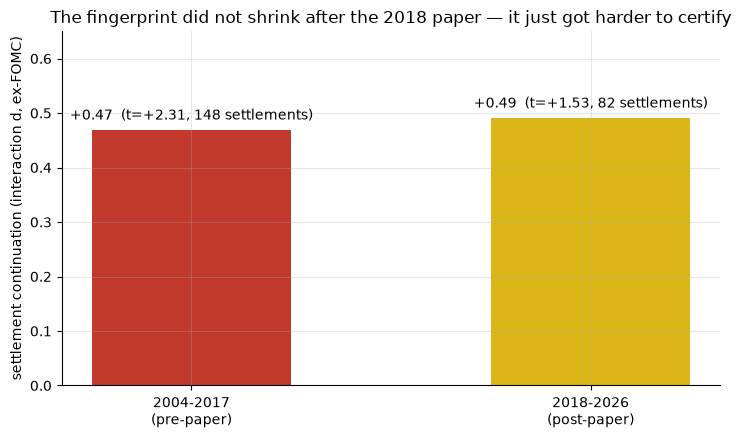

In [5]:
pre, post = R['fade_inter']['pre'], R['fade_inter']['post']
fig, ax = plt.subplots(figsize=(8.5, 4.6))
bars = ax.bar(['2004-2017\n(pre-paper)', '2018-2026\n(post-paper)'],
              [pre[0], post[0]], color=[RED, AMBER], width=.5)
for b, (d_, t_, n_) in zip(bars, [pre, post]):
    ax.text(b.get_x()+b.get_width()/2, d_+.02, f'{d_:+.2f}  (t={t_:+.2f}, {n_} settlements)',
            ha='center', fontsize=10)
ax.set_ylabel('settlement continuation (interaction d, ex-FOMC)')
ax.set_ylim(0, .65)
ax.set_title('The fingerprint did not shrink after the 2018 paper — it just got harder to certify')
plt.show()

## Why you can't cash it

Three walls, each fatal on its own:

1. **The VIX index is not a thing you can buy.** The fingerprint lives in the index print.
2. **The obvious rule earns nothing.** "At the settlement open, ride the gap's direction to the close" is worth **-0.024% per event** before costs (statistically zero) and about **-6.3%/yr** after futures-level costs.
3. **The contract that settles has already settled.** By the time the distorted open exists, the expiring future's payout is fixed; the surviving contracts track the index loosely.

A real footprint, an empty wallet: **Mirage**.

## Verdict

| Axis | Stamp |
|---|---|
| Signal | **MIXED** — real on the *fade-refusal* fingerprint (robust *t* ≈ 2.9, placebo p ≈ 0.003); none on the loud "wilder day" claims once the Fed overlap is stripped |
| Tradability | **MIRAGE** — untradable index, ~zero gross, negative net |
| Faded after 2018? | **MIXED** — the level effect died, the fingerprint didn't budge |

*Full numbers: [docs/results.md](../docs/results.md) · stats teardown: [02_for_the_quants.ipynb](02_for_the_quants.ipynb)*